# Instacart Market Basket Analysis

## Importing the required libraries

Hi there,
The goal of this project is to clean up the data from the app Instacart. With that, I will be able to to give some insight into the shopping habits of Instacart customers.
Also, in this project I will be showing what days of the week the customers order the most. What time they normally order, the most order products, etc.
I expect to find the answer for thoses questions, utilizing charts and other methods to vizulize the data efficiently.

In [1]:
# Import the libraries you'll need for this analysis
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
# Load the datasets
# Note: These files use semicolon (;) as the separator instead of comma
orders         = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
products       = pd.read_csv('/datasets/products.csv', sep=';')
departments    = pd.read_csv('/datasets/departments.csv', sep=';')
aisles         = pd.read_csv('/datasets/aisles.csv', sep=';')
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')

## Analyze your data

In the cells below, display the datasets using `.info()` and `.head()` to gain insights into their structure and content.

- `.info()`: Provides a concise summary of the dataset, including the data types, non-null counts, and memory usage.
- `.head()`: Displays the first few rows of the dataset, offering a quick overview of the data values.

In [3]:
# In this cell, type "orders" below this line and execute the cell
orders


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0
...,...,...,...,...,...,...
478962,3210681,5617,5,1,14,7.0
478963,3270802,112087,2,3,13,6.0
478964,885349,82944,16,2,11,6.0
478965,216274,4391,3,3,8,8.0


In [4]:
products
# In this cell, type "products" below this line and execute the cell


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
...,...,...,...,...
49689,49690,HIGH PERFORMANCE ENERGY DRINK,64,7
49690,49691,ORIGINAL PANCAKE & WAFFLE MIX,130,14
49691,49692,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR,130,14
49692,49693,SPRING WATER BODY WASH,127,11


Repeat this process for each dataset to understand the structure, including the types of columns and rows they contain. Add additional code cells as needed for your analysis.

In [5]:
# In this cell, type "orders.info() below this line and execute the cell
orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


The "Non-Null Count" column provides information about any missing values in each column of the dataset. With a total of 478,952 entries, observe any columns where the non-null count is less than this number to identify missing values.

In [7]:
# In this cell, run orders_products.info() below, but include the argument show_counts=True since this is a large file.
order_products = products.info(show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


Repeat the use of .info() on the remaining datasets to identify missing values and understand their structure. Check the "Non-Null Count" for each dataset to spot any columns with missing values.

## Find and Remove Missing Values

We noticed that some columns contain missing values.

Here are some useful code snippets:

```python
# Identify missing values in each column
print(dataset.isnull().sum())

# Display rows where a specific column has missing values
print(dataset[dataset['column_name'].isna()])

# Confirm no missing values remain
print(dataset.isnull().sum())
```

### `products` Data Frame

We will begin by addressing the missing values in the `products` data frame.

In [7]:
print(products[products['product_name'].isna()])# Display rows where the product_name column has missing values


       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


It seems suspicious that all rows with missing `product_name` might be associated with `aisle_id` 100 and `department_id` 21. Let’s verify this by checking if any rows with missing `product_name` have an `aisle_id` different from 100 and 21. This will help us confirm if the issue is isolated to this aisle or spread across others.

In [8]:
product_name = products[products['aisle_id'].isna() != 100]# Combine conditions to check for missing product names in aisles other than 100
print(product_name)

       product_id                                       product_name  \
0               1                         Chocolate Sandwich Cookies   
1               2                                   All-Seasons Salt   
2               3               Robust Golden Unsweetened Oolong Tea   
3               4  Smart Ones Classic Favorites Mini Rigatoni Wit...   
4               5                          Green Chile Anytime Sauce   
...           ...                                                ...   
49689       49690                      HIGH PERFORMANCE ENERGY DRINK   
49690       49691                      ORIGINAL PANCAKE & WAFFLE MIX   
49691       49692    ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR   
49692       49693                             SPRING WATER BODY WASH   
49693       49694                            BURRITO- STEAK & CHEESE   

       aisle_id  department_id  
0            61             19  
1           104             13  
2            94              7  
3  

In [9]:
product_name = products[products['department_id'].isna() != 21]
print(product_name)# Combine conditions to check for missing product names in aisles other than 21


       product_id                                       product_name  \
0               1                         Chocolate Sandwich Cookies   
1               2                                   All-Seasons Salt   
2               3               Robust Golden Unsweetened Oolong Tea   
3               4  Smart Ones Classic Favorites Mini Rigatoni Wit...   
4               5                          Green Chile Anytime Sauce   
...           ...                                                ...   
49689       49690                      HIGH PERFORMANCE ENERGY DRINK   
49690       49691                      ORIGINAL PANCAKE & WAFFLE MIX   
49691       49692    ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR   
49692       49693                             SPRING WATER BODY WASH   
49693       49694                            BURRITO- STEAK & CHEESE   

       aisle_id  department_id  
0            61             19  
1           104             13  
2            94              7  
3  

To better understand the missing product_name values, let’s determine what department_id 21 and aisle_id 100 represent by referencing the departments and aisles tables.

In [10]:
aisle_info = aisles[aisles['aisle_id'] == 100]# What is this aisle and department?
department_info = departments[departments['department_id'] == 21]
print(aisle_info)
print(department_info)

    aisle_id    aisle
99       100  missing
    department_id department
20             21    missing


In [11]:
products['aisle_id'] = products['aisle_id'].fillna('Unknown')
products['department_id'] = products['department_id'].fillna('Unknown')
#I used "fillna" to fill missing products.
# Fill missing product names with 'Unknown'


In [12]:
#After filling missing products names with "Unknown", theere are notmissing products in "aisle_id" and "department_id".


### `orders` data frame

Now let's fill in missing values from the `orders` table.

In [13]:
print(orders[orders['days_since_prior_order'].isna()]) 
#I've used "isna()" to check any missing data.
# Display rows where the days_since_prior_order column has missing values


        order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478895   2589657   205028             1          0                 16   
478896   2222353   141211             1          2                 13   
478922   2272807   204154             1          1                 15   
478926   2499542    68810             1          4                 19   
478945   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                         NaN  
100                     

In [14]:
#I have diplayed the "orders dataframe", pointing out the missing values for the "days_since_prior_order" columns.


In [15]:
problematic_orders = orders[(orders['days_since_prior_order'].isna()) & (orders['order_number'] > 1)] 
#Use the method in [35] to find missing data + 'order_number' > 1, to find it from 2th order on.
# Are there any missing values where it's not a customer's first order?


All of the missing `'days_since_prior_order'` values correspond to a customer's first ever order. This makes sense because there is no prior order! We'll leave the values as `NaN` so the column can remain numeric. Also, the `NaN` values shouldn't interfere with any calculations we might do using this column.

### `order_products` data frame

Now let's fill in missing values from the order_products table.

In [16]:
print(order_products[order_products['add_to_cart_order'].isna()])
# Display rows where the add_to_cart_order column has missing values

         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]


In [17]:
#That shows all the missing products in "add_to_cart_order" column.

In [18]:
min_value = order_products['add_to_cart_order'].min()
max_value = order_products['add_to_cart_order'].max()
print(f"Minimun value: {min_value}")
print(f"Maximun value: {max_value}")
# Use .min() and .max() to find the minimum and maximum values for this column.


Minimun value: 1.0
Maximun value: 64.0


In [19]:
print(order_products[order_products["add_to_cart_order"].isna()] == 1)
#Save all order IDs with at least one missing value in 'add_to_cart_order'

         order_id  product_id  add_to_cart_order  reordered
737         False       False              False      False
9926        False       False              False      False
14394       False       False              False      False
16418       False       False              False      False
30114       False       False              False       True
...           ...         ...                ...        ...
4505662     False       False              False      False
4511400     False       False              False      False
4517562     False       False              False      False
4534112     False       False              False      False
4535739     False       False              False       True

[836 rows x 4 columns]


In [20]:
#I tried to have the missing orders from "add_to_cart_order" == 1, in an atempt to have IDs with ate least one missing value.
    

In [21]:

order_with_missing_products = order_products[order_products["add_to_cart_order"].isna()]['order_id'].unique()
print(f"Number of orders with missing values: {len(order_with_missing_products)}")
products_per_order = order_products["order_id"].value_counts()
missing_order_sizes = products_per_order[order_with_missing_products]
order_over_64 = missing_order_sizes[missing_order_sizes > 64]
print(f"Orders with missing values that have >64 products: {len(order_over_64)}")

# Do all orders with missing values have more than 64 products?



Number of orders with missing values: 70
Orders with missing values that have >64 products: 70


In [22]:
#I tried to wornk on the missing values that have >64 products, but I also had to add all missing values first to understand the comparison between both of them.


In [23]:
order_without_missing_products = order_products.fillna(999)
print(order_without_missing_products)
order_products = order_products.astype('Int64')
print(order_products)
# Replace missing values with 999 and convert column to integer type


         order_id  product_id  add_to_cart_order  reordered
0         2141543       11440               17.0          0
1          567889        1560                1.0          1
2         2261212       26683                1.0          1
3          491251        8670               35.0          1
4         2571142        1940                5.0          1
...           ...         ...                ...        ...
4545002    577211       15290               12.0          1
4545003   1219554       21914                9.0          0
4545004    692640       47766                4.0          1
4545005    319435         691                8.0          1
4545006   1398151       28733                9.0          0

[4545007 rows x 4 columns]
         order_id  product_id  add_to_cart_order  reordered
0         2141543       11440                 17          0
1          567889        1560                  1          1
2         2261212       26683                  1          1
3          4

In [24]:
#I have changed the dataframe, replacing all the missing values to '999'. Also, i did convert the column to integer type.


For some reason, any item placed in the cart 65th or later has a missing value in the `'add_to_cart_order'` column. Maybe the data type of that column in the database could only hold integer values from 1 to 64. We've decided to replace the missing values with a code value, 999, that represents an unknown placed in cart order above 64. We also converted the column to integer data type. We just need to be careful to remember this if we perform calculations using this column during our analysis.

Other sensible code values we could've used are 0 or -1 because they don't show up elsewhere in the dataset and they don't have any real physical meaning for this variable.

Also note that, for orders with exactly 65 items, we could replace the missing value with 65. But we're going to neglect that for now since we can't determine the 65th item for all orders with 66 items or more.

## Find and Remove Duplicate Values from All the Datasets

Each dataset may contain duplicate rows, which can lead to redundancy and affect the accuracy of our analysis. To handle this:

1. Use the `.duplicated()` method to identify duplicate rows. This method returns a Boolean series where `True` indicates a duplicate row.
2. Apply the `.drop_duplicates()` method to remove these duplicate rows, ensuring a cleaner dataset.
3. Optionally, you can set the `keep` parameter in `.drop_duplicates()` to specify which duplicate to retain (`'first'` or `'last'`).

Here is some example code for reference:
```python
# Check for duplicates
print(dataset.duplicated().sum())  # Number of duplicate rows

# View duplicate rows
print(dataset[dataset.duplicated()]

# Remove duplicates
dataset = dataset.drop_duplicates().reset_index(drop=True)

# Confirm removal
print(dataset.duplicated().sum())  # Should return 0
```

Repeat this process for all datasets to ensure they are free of duplicate rows.

### `orders` data frame

In [25]:
print(orders.duplicated().sum())# Find the number of duplicate rows in the orders dataframe


15


In [26]:
# Jut utilized the metthod ".duplicate().sum()" to find how many duplicate rows we have in the 'orders' dataframe.


In [27]:
orders = orders.duplicated()
print(orders)
# View the duplicate rows


0         False
1         False
2         False
3         False
4         False
          ...  
478962    False
478963    False
478964    False
478965    False
478966    False
Length: 478967, dtype: bool


In [28]:
#I am not sure if I did right because I was confused with the differences between "View the duplicate rows" and "Applying the method to view the duplicate rows."


In [29]:
print(orders[orders.duplicated()])# Applying the method to view the duplicate rows


1         False
2         False
3         False
4         False
5         False
          ...  
478962    False
478963    False
478964    False
478965    False
478966    False
Length: 478965, dtype: bool


In [30]:
orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
orders = orders.drop_duplicates().reset_index(drop = True)
print(orders)# Remove duplicate orders


        order_id  user_id  order_number  order_dow  order_hour_of_day  \
0        1515936   183418            11          6                 13   
1        1690866   163593             5          5                 12   
2        1454967    39980             4          5                 19   
3        1768857    82516            56          0                 20   
4        3007858   196724             2          4                 12   
...          ...      ...           ...        ...                ...   
478947   3210681     5617             5          1                 14   
478948   3270802   112087             2          3                 13   
478949    885349    82944            16          2                 11   
478950    216274     4391             3          3                  8   
478951   2071924     1730            18          1                 14   

        days_since_prior_order  
0                         30.0  
1                          9.0  
2                       

In [31]:
#The dot told me I had to reload the orders data because "orders" has become a Series object instead of DataFrame.
#It also said The line, "orders = orders.duplicates()" overwrote the DataFrame with a Boolean Series, showing wich rows are duplicates.
#This part I am very confused.

In [32]:
print(orders.duplicated().sum())# Double check for duplicate rows


0


In [33]:
#As expected, The result was zero after using the method to confirm removal.


### `products` data frame

In [34]:
print(products.duplicated().sum())# Check for fully duplicate rows


0


In [35]:
#After checking if there were any duplicates, the result came out to be zero duplicates in the "products" data frame.


In [36]:
products = pd.read_csv('/datasets/products.csv', sep=';')
print(products.duplicated(subset=['product_id']).sum())# Check for just duplicate product IDs using subset='product_id' in duplicated()


0


In [37]:
# I've checked for any duplicate  only on the "product_id" column.


Hint: To identify duplicate product names more effectively, convert the names to lowercase for consistent comparison. Use the .str.lower() method on the product_name column to standardize the text before checking for duplicates.

In [38]:
products['product_name'].str.lower()
products.duplicated(subset=['product_name']).sum()
# Check for just duplicate product names (convert names to lowercase to compare better)


1257

Let's see what that looks like in our dataset :

In [39]:
products[products['product_name'].str.lower() == 'high performance energy drink']

,product_id,product_name,aisle_id,department_id
22540,22541,High Performance Energy Drink,64,7
49689,49690,HIGH PERFORMANCE ENERGY DRINK,64,7


In [40]:
products = pd.read_csv('/datasets/products.csv', sep=';')
products = products['product_name'].drop_duplicates().reset_index(drop = True)
print(products)
# Drop duplicate product names (case insensitive)


0                               Chocolate Sandwich Cookies
1                                         All-Seasons Salt
2                     Robust Golden Unsweetened Oolong Tea
3        Smart Ones Classic Favorites Mini Rigatoni Wit...
4                                Green Chile Anytime Sauce
                               ...                        
48432                        HIGH PERFORMANCE ENERGY DRINK
48433                        ORIGINAL PANCAKE & WAFFLE MIX
48434      ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR
48435                               SPRING WATER BODY WASH
48436                              BURRITO- STEAK & CHEESE
Name: product_name, Length: 48437, dtype: object


In [41]:
#Just utilized the method to remove duplicates in the "product" DataFrame.

### `departments` data frame

In [42]:
# Check for duplicate entries in the departments dataframe
print(departments.duplicated().sum())

0


In [43]:
#No duplicates anymore for "departments".

### `aisles` data frame

In [44]:
print(aisles.duplicated().sum())# Check for aisles entries in the departments dataframe


0


### `order_products` data frame

In [45]:
print(order_products.duplicated().sum())
# Check for duplicate entries in the order_products dataframe


0


In [46]:
#No duplicates anymore for "order_products".


We have now successfully cleaned our data. Let's begin our exploratory data analysis.

# [A] Easy (must complete all to pass)

### [A1] Verify that the `'order_hour_of_day'` and `'order_dow'` values in the `orders` tables are sensible (i.e. `'order_hour_of_day'` ranges from 0 to 23 and `'order_dow'` ranges from 0 to 6)

To verify that the values in the `order_hour_of_day` and `order_dow` columns are sensible:

1. **Check unique values**: Use `.unique()` on each column to extract all distinct values present.
2. **Sort the results**: Use `sorted()` to arrange the unique values in ascending order for easier verification.
3. **Validate ranges**:
   - Ensure `order_hour_of_day` values range from 0 to 23 (representing hours of the day).
   - Ensure `order_dow` values range from 0 to 6 (representing days of the week).

This process confirms that the data aligns with expected ranges and there are no out-of-bound or invalid entries.

In [47]:
print("Unique hours:", sorted(orders['order_hour_of_day'].unique()))

Unique hours: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [48]:
# With that I could confirm the range for the hours is in fact between 0 to 23.

In [49]:
print("Unique days:", sorted(orders['order_dow'].unique()))

Unique days: [0, 1, 2, 3, 4, 5, 6]


In [50]:
# With that I could confirm the range for the days is in fact between 0 to 6.

### [A2] What time of day do people shop for groceries?

To determine the time of day people shop for groceries, analyze the order_hour_of_day column in the orders dataset. Use .value_counts() to count the number of orders placed at each hour, and then sort the results by the hour for a clear chronological order.

Finally, visualize the data with a bar plot to easily observe the shopping trends across different times of the day.

10    40578
11    40032
15    39789
14    39631
13    39007
16    38112
12    38034
9     35896
17    31930
18    25510
8     25024
19    19547
20    14624
7     13043
21    11019
22     8512
23     5611
6      4215
0      3180
1      1763
5      1371
2       989
3       770
4       765
Name: order_hour_of_day, dtype: int64
[765, 770, 989, 1371, 1763, 3180, 4215, 5611, 8512, 11019, 13043, 14624, 19547, 25024, 25510, 31930, 35896, 38034, 38112, 39007, 39631, 39789, 40032, 40578]


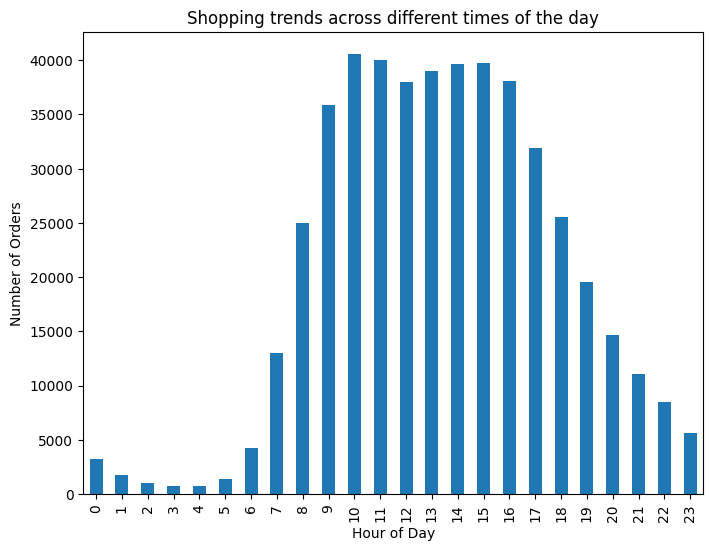

In [51]:
print(orders['order_hour_of_day'].value_counts())
print(sorted(orders['order_hour_of_day'].value_counts()))
hour_counts = orders['order_hour_of_day'].value_counts().sort_index()
ax = hour_counts.plot(
    kind='bar',
    title='Shopping trends across different times of the day',
    figsize=[8,6],
    xlabel='Hour of Day',
    ylabel='Number of Orders'
)
plt.show()



Most orders occur between 9:00 AM and 5:00 PM, with peaks at 10:00 AM and 3:00 PM

### [A3] What day of the week do people shop for groceries?

To figure out what day of the week people shop for groceries, analyze the order_dow column in the orders dataset. Use .value_counts() to count the number of orders for each day of the week, and then sort the results by the day index to maintain the correct order.

Visualize the data with a bar plot to clearly observe shopping patterns across the days of the week.

0    84090
1    82185
2    65833
5    63488
6    62649
3    60912
4    59810
Name: order_dow, dtype: int64
[59810, 60912, 62649, 63488, 65833, 82185, 84090]


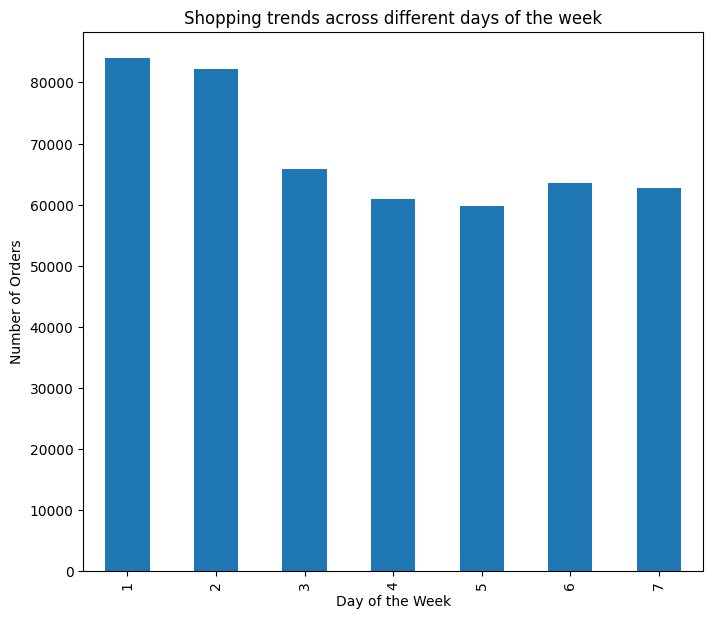

In [25]:
print(orders['order_dow'].value_counts())
print(sorted(orders['order_dow'].value_counts()))
orders_per_day = orders['order_dow'].value_counts().sort_index()
orders_per_day.index = orders_per_day.index + 1
ax = orders_per_day.plot(
    kind='bar',
    title='Shopping trends across different days of the week',
    figsize=[8,7],
    xlabel='Day of the Week',
    ylabel='Number of Orders'
)
plt.show()

In [9]:
# Student comments: I did not see anthing about bar plot in the instructions. That is why I did not do it.

The data dictionary does not state which integer corresponds to which day of the week. Assuming Sunday = 0, then people place more orders at the beginning of the week (Sunday and Monday).

### [A4] How long do people wait until placing another order?

To understand how long people wait before placing another order, analyze the days_since_prior_order column in the orders dataset. Use .value_counts() to count how many orders were placed for each interval of days, then sort the results by the number of days for clarity.

Visualize the data using a bar plot to observe patterns in ordering frequency over time.

30.0    51338
7.0     44579
6.0     33931
4.0     31007
3.0     30225
5.0     30096
2.0     27141
8.0     25361
1.0     20179
9.0     16754
14.0    13992
10.0    13310
13.0    11737
11.0    11467
12.0    10658
0.0      9589
15.0     9416
16.0     6588
21.0     6448
17.0     5498
20.0     5302
18.0     4972
19.0     4939
22.0     4514
28.0     3745
23.0     3337
24.0     3015
27.0     2986
25.0     2711
29.0     2673
26.0     2640
Name: days_since_prior_order, dtype: int64
[2640, 2673, 2711, 2986, 3015, 3337, 3745, 4514, 4939, 4972, 5302, 5498, 6448, 6588, 9416, 9589, 10658, 11467, 11737, 13310, 13992, 16754, 20179, 25361, 27141, 30096, 30225, 31007, 33931, 44579, 51338]


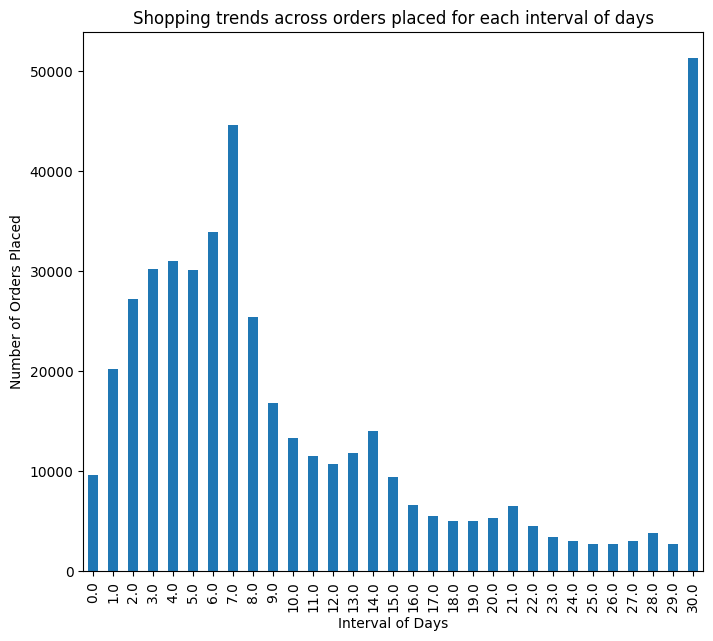

In [18]:
print(orders['days_since_prior_order'].value_counts())
print(sorted(orders['days_since_prior_order'].value_counts()))
order_placed_per_interval_of_days= orders['days_since_prior_order'].value_counts().sort_index()
order_placed_per_interval_of_days.plot(
    kind='bar',
    title='Shopping trends across orders placed for each interval of days',
    figsize=[8,7],
    xlabel='Interval of Days',
    ylabel='Number of Orders Placed'
)
plt.show()

The 0 values probably correspond to customers who placed more than one order on the same day.

The max value of 30 days and the high spike at that value is puzzling though. The spike might be explained by people who set up recurring subscriptions to automatically order once a month. But that doesn't explain why there are no values above 30 days. I would expect many customers to place orders less often than once a month. Maybe those customers were intentionally excluded from the dataset.

Disregarding the spike at 30 days, most people wait between 2 to 10 days in between orders. The most common wait time is 7 days. In other words, it's common for people to place weekly grocery orders. Interestingly, in the tail of the distribution we also see small spikes at 14, 21, and 28 days. These would correspond to orders every 2, 3, or 4 weeks.

# [B] Medium (must complete all to pass)

### [B1] Is there a difference in `'order_hour_of_day'` distributions on Wednesdays and Saturdays? Plot the bar charts for both days and describe the differences that you see.

To determine if there's a difference in the `order_hour_of_day` distributions on Wednesdays and Saturdays, follow these steps:

1. **Create masks** for Wednesday (`order_dow == 3`) and Saturday (`order_dow == 6`) to filter the orders data.
2. **Count the order hours** for each day using `.value_counts()` and sort them by hour with `.sort_index()` for clarity.
3. **Combine the counts** for both days into a single DataFrame using `pd.concat()`, and label the columns for easier interpretation.

After preparing the data, plot bar charts for both days to visually compare the distribution of order times. Look for patterns such as peaks or differences in the busiest times throughout the day.

# I have created masks for both days in orders to filter the orders data. I also counted the order hour for each day, showing how many orders hourly for both day. Lastly, I combine both days's counts to compare the numbers.

In [20]:
wednesday_mask = orders['order_dow'] == 3
print(wednesday_mask)

0         False
1         False
2         False
3         False
4         False
          ...  
478962    False
478963     True
478964    False
478965     True
478966    False
Name: order_dow, Length: 478967, dtype: bool


In [28]:
saturday_mask = orders['order_dow'] == 6
print(saturday_mask)

0          True
1         False
2         False
3         False
4         False
          ...  
478962    False
478963    False
478964    False
478965    False
478966    False
Name: order_dow, Length: 478967, dtype: bool


0      373
1      215
2      121
3      101
4      108
5      170
6      643
7     1732
8     3125
9     4490
10    5026
11    5004
12    4688
13    4674
14    4774
15    5163
16    4976
17    4175
18    3463
19    2652
20    1917
21    1450
22    1154
23     718
Name: order_hour_of_day, dtype: int64


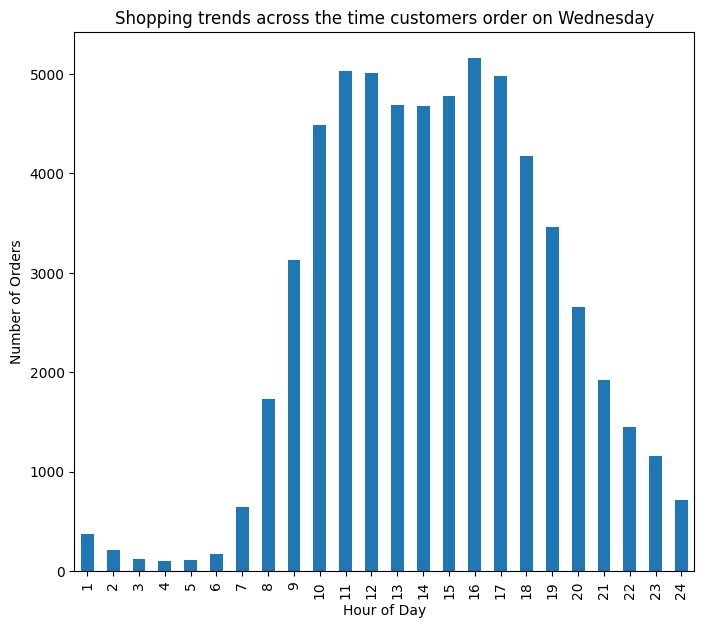

In [29]:
wed_counts = (
    orders.loc[wednesday_mask, 'order_hour_of_day'].value_counts().sort_index())
print(wed_counts)
wed_counts.index = wed_counts.index + 1
wed_distribution = wed_counts.plot(
    kind='bar',
    title='Shopping trends across the time customers order on Wednesday',
    figsize=[8,7],
    xlabel='Hour of Day',
    ylabel='Number of Orders'
)
plt.show()
    


0      464
1      254
2      177
3      125
4      118
5      161
6      451
7     1619
8     3246
9     4311
10    4919
11    5116
12    5132
13    5323
14    5375
15    5188
16    5029
17    4295
18    3338
19    2610
20    1847
21    1473
22    1185
23     893
Name: order_hour_of_day, dtype: int64


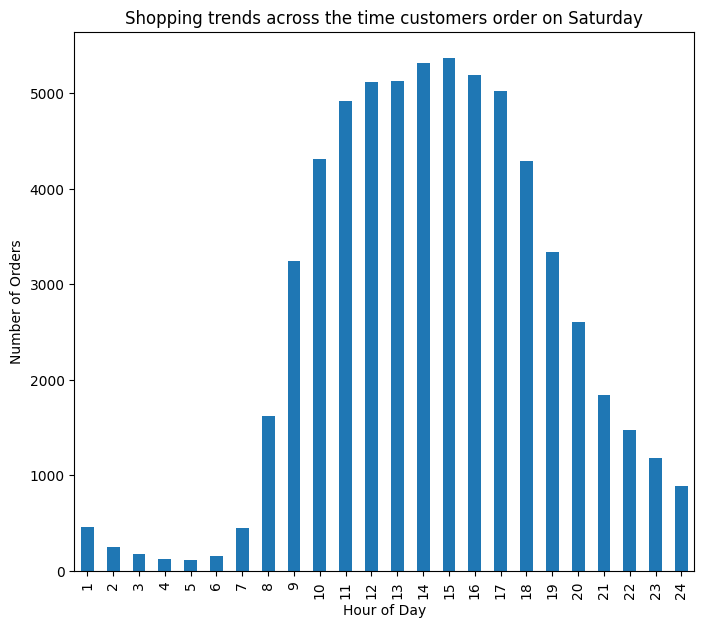

In [30]:
sat_counts = (
    orders.loc[saturday_mask, 'order_hour_of_day'].value_counts().sort_index())
print(sat_counts)
sat_counts.index = sat_counts.index + 1
sat_distribution = sat_counts.plot(
    kind='bar',
    title='Shopping trends across the time customers order on Saturday',
    figsize=[8,7],
    xlabel='Hour of Day',
    ylabel='Number of Orders'
)
plt.show()

In [58]:
combined_data = pd.concat([wed_counts, sat_counts], axis=1)
combined_data.columns = ['Wednesday', 'Saturday']
print(combined_data)

    Wednesday  Saturday
0         373       464
1         215       254
2         106       177
3         101       125
4         108       118
5         170       161
6         643       451
7        1732      1619
8        3125      3246
9        4490      4311
10       5026      4919
11       5004      5116
12       4688      5132
13       4674      5323
14       4774      5375
15       5163      5188
16       4976      5029
17       4175      4295
18       3463      3338
19       2652      2610
20       1917      1847
21       1450      1473
22       1154      1185
23        718       893


There's a small dip from 11h to 13h on Wednesdays. This dip is absent on Saturdays. Maybe this dip can be attributed to people who don't use Instacart because they have lunch somewhere between 11h and 13h.

### [B2] What's the distribution for the number of orders per customer?

To explore the distribution of the number of orders per customer:

1. **Group the data** by `user_id` to calculate the total number of orders for each customer. Use `.groupby('user_id')` and count the `order_id` for each group.
2. **Sort the results** using `.sort_values()` for better readability.
3. **Visualize the distribution** using a histogram to observe how many orders most customers typically place.

Adjust the number of bins in the histogram to refine the visualization and better capture the pattern.

In [59]:
orders_per_customer = orders.groupby('user_id')['order_id'].count().sort_values(ascending=False)
print(orders_per_customer.head(10))

user_id
149605    28
193164    26
78375     25
66664     24
134511    24
148162    24
183981    23
6045      23
53684     23
114835    23
Name: order_id, dtype: int64


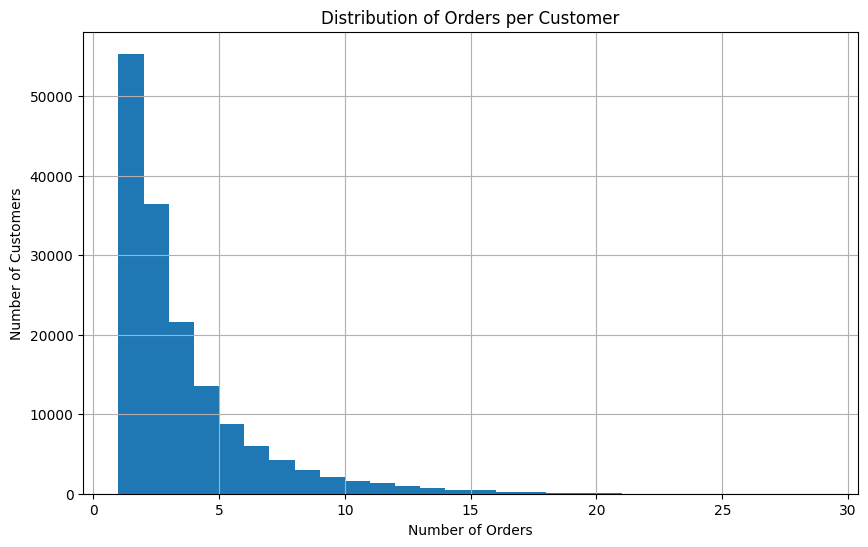

In [61]:
bins = range(1, orders_per_customer.max() + 2)

ax = orders_per_customer.hist(bins=bins, figsize=(10, 6))
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Number of Customers')
ax.set_title('Distribution of Orders per Customer')
plt.show()

    


Most customers in the dataset have placed between 1 and 10 orders, with number of orders per customer sharply decreasing after just 1 order.

### [B3] What are the top 20 popular products (display their id and name)?

To identify the top 20 most popular products:

1. **Merge the datasets**: Combine `order_products` and `products` on `product_id` to access both the product IDs and names in a single DataFrame.
2. **Group the data**: Group by both `product_id` and `product_name` to aggregate the order counts for each product using `.size()`.
3. **Sort the results**: Use `.sort_values(ascending=False)` to rank products by their popularity.
4. **Display the top 20**: Use `.head(20)` to focus on the most frequently ordered products.
5. **Visualize the results**: Create a bar chart to highlight the top products and their order counts.

This will give you a clear view of the most popular products and their ranking.


In [33]:
merged_data_sets = pd.merge(order_products, products, on='product_id')
print(merged_data_sets)

         order_id  product_id  add_to_cart_order  reordered  \
0         2141543       11440               17.0          0   
1          147172       11440                7.0          1   
2         3341719       11440                4.0          1   
3         1938779       11440                8.0          1   
4         1728338       11440               23.0          0   
...           ...         ...                ...        ...   
4545002    267402       45226               14.0          0   
4545003   2621676       25201               10.0          0   
4545004    937623       49153                2.0          0   
4545005    532895        8182                1.0          0   
4545006   3132243       40024                1.0          0   

                               product_name  aisle_id  department_id  
0            Chicken Breast Tenders Breaded       129              1  
1            Chicken Breast Tenders Breaded       129              1  
2            Chicken Breast Te

In [ ]:
#I have succesfully merged the datasets

In [ ]:
# I was able to group both product_id and product_id to aggregate the order counts.

In [ ]:
# I checked and validated that the top 20 products are indeed produce.

In [ ]:
#I did create the chart to illustrate the top products along their order counts.

In [ ]:
grouping_data = (merged_data_sets.groupby(['product_id', 'product_name']).size())
print(grouping_data)

In [ ]:
sort_grouping_data =  (merged_data_sets.groupby(['product_id', 'product_name']).size().sort_values(ascending=False))
print(sort_grouping_data)

In [ ]:
display_top_20 = (merged_data_sets.groupby(['product_id', 'product_name']).size().sort_values(ascending=False).head(20))
print(display_top_20)
ax = display_top_20.plot(x = 'top products',
                    y = 'order counts',
                    figsize = [12,6],
                    kind = 'bar',
                    title ='Top 20 Most Popular Products'
)
ax.set_xlabel('Products')
ax.set_ylabel('Order Count')
plt.xticks(rotation=45, ha='right')
plt.show()


The top 20 items are all produce, except for the milk. Looks like people want delicious and nutritious!

# [C] Hard (must complete at least two to pass)

### [C1] How many items do people typically buy in one order? What does the distribution look like?
To analyze how many items people typically buy in one order:

1. **Group the data** by `order_id` and count the number of products (`product_id`) in each order using `.count()`. This gives the number of items in each order.
2. **Aggregate the counts**: Use `.value_counts()` to determine how frequently different order sizes occur, and then sort the results with `.sort_index()` to organize by the number of items.
3. **Visualize the distribution**: Use a bar plot to show the frequency of orders for each size, with the x-axis representing the number of items and the y-axis representing the number of orders.

This will help you understand the typical size of a grocery order and identify any trends in purchasing behavior.

In [65]:
items_per_order = order_products.groupby('order_id')['product_id'].count()
print(items_per_order.head(10))

order_id
4     13
9     15
11     5
19     3
20     8
31    10
48     8
56    10
61    12
68     9
Name: product_id, dtype: int64


In [66]:
# The result is showing the number of products in each order

In [67]:
order_size_distribution = items_per_order.value_counts().sort_index()
print(order_size_distribution.head(20))

1     21847
2     26292
3     29046
4     31054
5     31923
6     31698
7     30822
8     28539
9     25742
10    23248
11    20406
12    18539
13    16497
14    14472
15    12696
16    11465
17    10002
18     8726
19     7612
20     6771
Name: product_id, dtype: int64


In [68]:
# Now we can see how often different sizes occur.

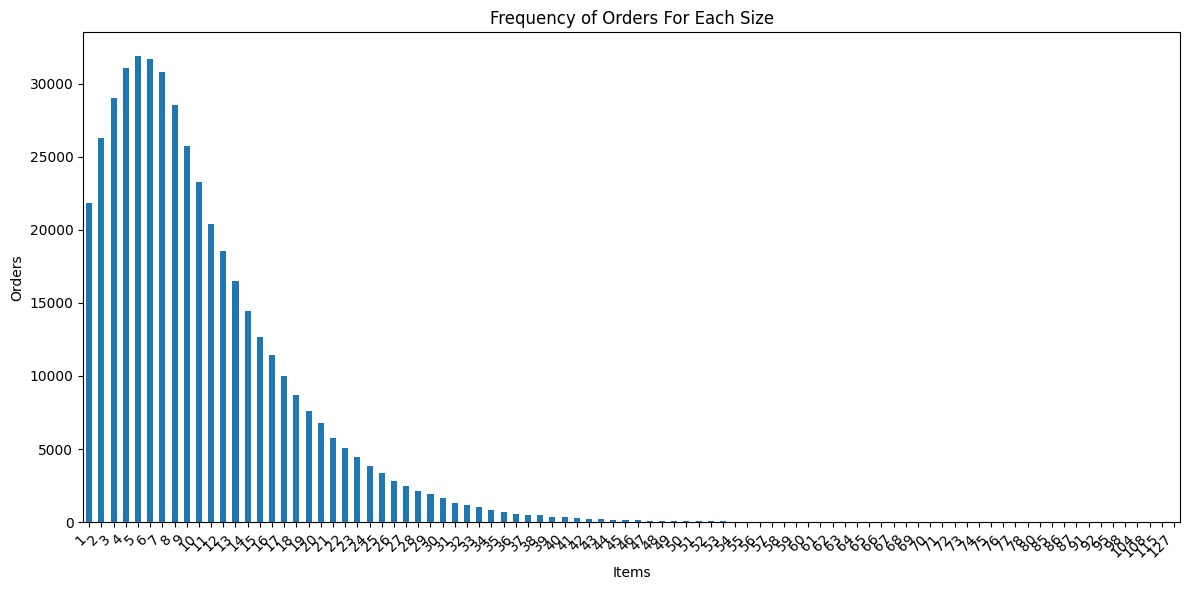

In [69]:
ax = order_size_distribution.plot(x = 'number of items',
                    y = 'number of orders',
                    figsize = [12,6],
                    kind = 'bar',
                    title ='Frequency of Orders For Each Size'
)
ax.set_xlabel('Items')
ax.set_ylabel('Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [70]:
#I have tried to utilized the "plt.tight_layout()" method, but the items were still cut off.

Most of the order numbers are in the tail of the distribution. To get a better look at the non-tail part, let's choose a value in the tail as a cutoff and just plot order with fewer than that many items. An order size of 35 items is far enough into the tail for this.

The typical order contains 5 or 6 items, with most orders having between 1 and 20 items.

### [C2] What are the top 20 items that are reordered most frequently (display their names and product IDs)?

To find the top 20 most frequently reordered items:

1. **Filter the data**: Use `order_products['reordered'] == 1` to isolate only the products that have been reordered.
2. **Merge the datasets**: Combine the filtered `order_products` with the `products` dataset on `product_id` to get both the product names and IDs.
3. **Group the data**: Group by both `product_id` and `product_name` to calculate how many times each product was reordered, using `.size()`.
4. **Sort the results**: Use `.sort_values(ascending=False)` to rank the products by reorder frequency.
5. **Display the top 20**: Use `.head(20)` to focus on the most frequently reordered products.
6. **Visualize the data**: Create a bar chart to showcase the top reordered items and their frequencies.

This process highlights the products that customers consistently return to and reorder.

In [71]:
items_reordered = order_products['reordered'] == 1
print(items_reordered)

0          False
1           True
2           True
3           True
4           True
           ...  
4545002     True
4545003    False
4545004     True
4545005     True
4545006    False
Name: reordered, Length: 4545007, dtype: boolean


In [72]:
# I just filtered the products that have been reordered.

In [34]:
merged_data_sets = pd.merge(order_products, products, on='product_id')
print(merged_data_sets)

         order_id  product_id  add_to_cart_order  reordered  \
0         2141543       11440               17.0          0   
1          147172       11440                7.0          1   
2         3341719       11440                4.0          1   
3         1938779       11440                8.0          1   
4         1728338       11440               23.0          0   
...           ...         ...                ...        ...   
4545002    267402       45226               14.0          0   
4545003   2621676       25201               10.0          0   
4545004    937623       49153                2.0          0   
4545005    532895        8182                1.0          0   
4545006   3132243       40024                1.0          0   

                               product_name  aisle_id  department_id  
0            Chicken Breast Tenders Breaded       129              1  
1            Chicken Breast Tenders Breaded       129              1  
2            Chicken Breast Te

In [ ]:
#Combined the datasets using "pd.merge".

In [ ]:
reordered_items = merged_data_sets[merged_data_sets['reordered'] == 1]
top_reordered = reordered_items.groupby(['product_id', 'product_name']).size()
print(top_reordered)

In [ ]:
# I grouped product_id and product_name to see how many times they have been reordered.

In [ ]:
top_20_reordered = top_reordered.sort_values(ascending=False).head(20)
print(top_20_reordered)


In [ ]:
# I have got the rank of the products by reorder frequency, and pull the top 20 most frequent products reordered.

In [ ]:
visualize_the_data = top_20_reordered.plot(x='top reordered items',
                                         y='frequencies',
                                         title='Top reordred items and their frequencies',
                                         figsize=[10,6],
                                         kind='bar'
)
plt.show()

In [ ]:
# After all that anlysis, I was able to verify that produce and dairy are the most reordered products.

It looks like produce and dairy comprise the most reordered products as well. It makes sense that perishables would be the most reordered items.

### [C3] For each product, what proportion of its orders are reorders?

To calculate the proportion of orders for each product that are reorders:

1. **Merge the datasets**: Combine `order_products` with the `products` dataset to access product names and IDs in the same DataFrame.
2. **Group the data**: Group by `product_id` and `product_name` to isolate each product's order history.
3. **Calculate the mean of `reordered`**: Use `.mean()` on the `reordered` column to compute the proportion of orders for each product that were reorders. The value represents the reorder rate.
4. **Sort the results**: Use `.sort_values(ascending=False)` to rank products by their reorder rates.
5. **Convert to a DataFrame**: Use `.reset_index()` to organize the grouped data into a readable DataFrame.
6. **Optional Sorting**: Sort the results by `product_id` or another column for better clarity.

This approach provides insights into how frequently each product is reordered, helping identify customer favorites or staples.


### [C4] For each customer, what proportion of their products ordered are reorders?

To calculate the proportion of products reordered by each customer:

1. **Merge the datasets**: Combine `order_products` with `orders` to link order and customer information.
2. **Group the data**: Group by `user_id` to focus on each customer's ordering behavior.
3. **Calculate the mean of `reordered`**: Use `.mean()` on the `reordered` column to determine the proportion of products reordered by each customer.
4. **Sort the results**: Use `.sort_values(ascending=False)` to identify customers with the highest reorder rates.
5. **Convert to a DataFrame**: Use `.reset_index()` to format the grouped data into a structured DataFrame for further analysis.

This analysis reveals the extent to which individual customers reorder products, providing insights into customer loyalty and preferences.


### [C5] What are the top 20 items that people put in their carts first?

To identify the top 20 items that people most frequently add to their carts first:

1. **Merge the datasets**: Combine `order_products` with `products` to link product names and IDs.
2. **Filter the data**: Focus on rows where `add_to_cart_order` equals 1, indicating the first item added to the cart.
3. **Group the data**: Group by `product_id` and `product_name` to aggregate the count of how often each product was the first in a cart.
4. **Count occurrences**: Use `.count()` to calculate the total number of times each product was the first added.
5. **Sort the results**: Use `.sort_values(ascending=False)` to rank products by their first-in-cart frequency.
6. **Display the top 20**: Use `.head(20)` to extract the most popular first-in-cart items.

This provides insights into which products customers prioritize in their shopping process.


The products that are most often placed into the cart first are produce, dairy, and beverages such as soda or water. I couldn't really say why that is without experience using Instacart because this could have more to do with app design than properties of the products. I do notice that there is considerable overlap between this result and the previous result for most popular and most reordered item types. It could simply be that the app prioritizes popular items as the first suggested purchases, so it happens to be more convenient for customers to place these items in their cart first.